## Pós-graduação em Engenharia de Software - PUC Rio

# 📊 Previsão de Retenção de Funcionários

## 🎯 Objetivo

Este projeto tem como objetivo predizer se um funcionário irá deixar a empresa com base em características como nível educacional, cidade, idade, experiência e nível salarial.

## 🧠 Contexto

A retenção de talentos é um dos principais desafios das organizações modernas. O custo para preencher estas vagas e treinar novos funcionários acaba tornando o processo lento e muito caro.

Através de técnicas de Machine Learning, é possível antecipar comportamentos e apoiar decisões estratégicas que fizam aumentar o grau de satisfação dos funcionários e evitar que deixem a empresa.

## 📁 Dataset

O dataset utilizado contém informações de funcionários e está disponível publicamente no Kaggle:
https://www.kaggle.com/datasets/tawfikelmetwally/employee-dataset


Com base nos requisitos do MVP, realizamos o download do arquivo em formato raw e o disponibilizamos no GitHub:
https://raw.githubusercontent.com/FabriciodSantosSilva/mvp3-employee-retention-ml/main/data/Employee.csv

##  Importação das Bibliotecas

Nesta etapa, importamos as bibliotecas necessárias para manipulação de dados, construção e avaliação dos modelos de Machine Learning.

Utilizamos principalmente a biblioteca Scikit-Learn para criação dos pipelines, treinamento dos modelos e validação.

In [ ]:
# configuração para não exibir os warnings
import warnings
warnings.filterwarnings("ignore")

# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização (opcional, mas usado nos gráficos)
import matplotlib.pyplot as plt

# Pré-processamento
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer

# Modelos de Machine Learning
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# Pipeline e validação
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV

# Métricas
from sklearn.metrics import accuracy_score, f1_score

# Serialização do modelo
import pickle

## Imports necessários
#import pandas as pd
#import numpy as np
#import matplotlib.pyplot as plt
#from sklearn.preprocessing import OneHotEncoder, StandardScaler
#from sklearn.preprocessing import MinMaxScaler
#from sklearn.model_selection import train_test_split
#from sklearn.model_selection import KFold
#from sklearn.model_selection import StratifiedKFold
#from sklearn.model_selection import cross_val_score
#from sklearn.model_selection import GridSearchCV
#from sklearn.metrics import accuracy_score
#from sklearn.pipeline import Pipeline
#from sklearn.tree import DecisionTreeClassifier
#from sklearn.neighbors import KNeighborsClassifier
#from sklearn.naive_bayes import GaussianNB
#from sklearn.svm import SVC
#
#from sklearn.compose import ColumnTransformer
#
##Bibliotecas necessarias para baixar o arquivo do dataset employee
#import kagglehub
#import os
#from sklearn.preprocessing import LabelEncoder
#
##Biblioteca para exportar o modelo e encoders
#import pickle
#

##  Carregamento dos Dados

Nesta etapa realizamos a importação do dataset diretamente de uma URL pública, conforme requisito do MVP.

In [ ]:
# 1. Download do dataset via KaggleHub
dataset = pd.read_csv("https://raw.githubusercontent.com/FabriciodSantosSilva/mvp3-employee-retention-ml/refs/heads/main/data/Employee.csv")



,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1
5,Bachelors,2016,Bangalore,3,22,Male,No,0,0
6,Bachelors,2015,New Delhi,3,38,Male,No,0,0
7,Bachelors,2016,Bangalore,3,34,Female,No,2,1
8,Bachelors,2016,Pune,3,23,Male,No,1,0
9,Masters,2017,New Delhi,2,37,Male,No,2,0


###  Análise Exploratória

Aqui analisamos a estrutura do dataset, tipos de dados e possíveis inconsistências.

In [ ]:
# Visualizar as primeiras linhas para confirmar a carga
dataset.head(10)

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1
5,Bachelors,2016,Bangalore,3,22,Male,No,0,0
6,Bachelors,2015,New Delhi,3,38,Male,No,0,0
7,Bachelors,2016,Bangalore,3,34,Female,No,2,1
8,Bachelors,2016,Pune,3,23,Male,No,1,0
9,Masters,2017,New Delhi,2,37,Male,No,2,0


###  Pré-processamento dos Dados

Os dados categóricos são tratados com OneHotEncoder e os dados numéricos são padronizados com StandardScaler, utilizando um Pipeline do Scikit-Learn.

Essa abordagem garante consistência entre treino e produção.

In [ ]:
categorical_cols = ['Education', 'City', 'Gender', 'EverBenched']
numerical_cols = ['JoiningYear', 'PaymentTier', 'Age', 'ExperienceInCurrentDomain']

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
        ("num", StandardScaler(), numerical_cols)
    ]
)

# Garantindo que o Target é inteiro e sem valores nulos
dataset['LeaveOrNot'] = pd.to_numeric(dataset['LeaveOrNot'], errors='coerce').astype(int)

###  Separação dos Dados em Treino e Teste (Holdout)

Nesta etapa, os dados são divididos em dois conjuntos:

- **Treino**: utilizado para treinar o modelo
- **Teste**: utilizado para avaliar o desempenho do modelo em dados não vistos

Foi utilizada a técnica de **holdout com estratificação**, garantindo que a proporção das classes (funcionários que saem ou permanecem) seja mantida em ambos os conjuntos.

A estratificação é importante para evitar viés na avaliação do modelo, especialmente em problemas de classificação.

A utilização de uma semente aleatória garante a reprodutibilidade dos resultados.

In [ ]:
# Separação entre variáveis independentes (X) e variável alvo (y)
X = dataset.drop("LeaveOrNot", axis=1)
y = dataset["LeaveOrNot"]

# Definição dos parâmetros
test_size = 0.20 # tamanho do conjunto de teste
seed = 7 # semente aleatória

# Separação em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=test_size,
    shuffle=True,
    random_state=seed,
    stratify=y
) # holdout com estratificação

# Verificação das dimensões
print("Tamanho do conjunto de treino:", X_train.shape)
print("Tamanho do conjunto de teste:", X_test.shape)

# Parâmetros e partições da validação cruzada
scoring = 'accuracy'
num_particoes = 10
kfold = StratifiedKFold(n_splits=num_particoes, shuffle=True, random_state=seed) # validação cruzada com estratificação

Tamanho do conjunto de treino: (3722, 8)
Tamanho do conjunto de teste: (931, 8)


## Modelagem e Inferência

### Criação e avaliação de modelos: linha base

Foram utilizados os seguintes algoritmos:
- KNN
- Árvore de Decisão
- Naive Bayes
- SVM

Os modelos foram avaliados utilizando validação cruzada.
O modelo SVN se destacou nesta primeira etapa, seguido dos modelos KNN e Árvore de Decisão.



KNN: 0.805204 (0.013719)
CART: 0.806550 (0.014096)
NB: 0.696131 (0.019544)
SVM: 0.842280 (0.012711)


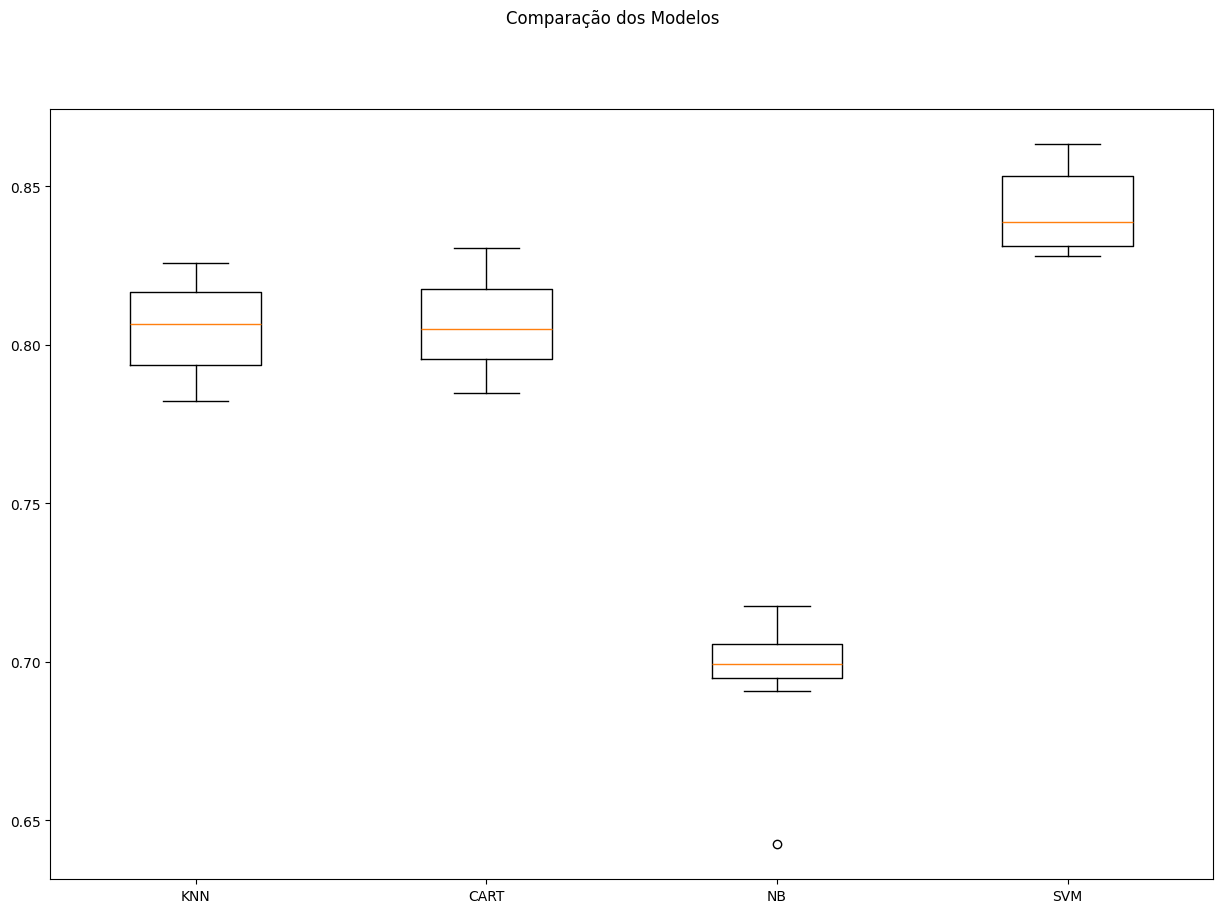

In [ ]:
np.random.seed(7) # definindo uma semente global

# Lista que armazenará os modelos
models = []

# Criando os modelos e adicionando-os na lista de modelos
models.append(('KNN', Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier())
])))

models.append(('CART', Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier())
])))

models.append(('NB', Pipeline([
    ("preprocessor", preprocessor),
    ("model", GaussianNB())
])))

models.append(('SVM', Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC())
])))

# Listas para armazenar os resultados
results = []
names = []

# Avaliação dos modelos
for name, model in models:
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

# Boxplot de comparação dos modelos
fig = plt.figure(figsize=(15,10))
fig.suptitle('Comparação dos Modelos')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

### Criação e avaliação de modelos: dados padronizados e normalizados

Nesta etapa, foram testadas três estratégias de tratamento das variáveis numéricas:

- **Sem normalização (orig)**: os dados são utilizados na forma original
- **Padronização (StandardScaler)**: transforma os dados para média 0 e desvio padrão 1
- **Normalização (MinMaxScaler)**: ajusta os dados para um intervalo entre 0 e 1

Para garantir consistência e evitar vazamento de dados, foi utilizado um **Pipeline do Scikit-Learn**, que encapsula tanto o pré-processamento quanto o modelo.

A avaliação dos modelos foi realizada utilizando **validação cruzada estratificada (Stratified K-Fold)**, o que permite uma estimativa mais robusta do desempenho dos modelos, reduzindo o risco de overfitting.

Para cada combinação de modelo e pré-processamento, foram calculadas:

**Acurácia média**

Os resultados foram então ordenados do melhor para o pior desempenho e apresentados em formato de tabela e gráfico boxplot, permitindo uma análise visual da variabilidade dos modelos.

Essa abordagem permite identificar não apenas o melhor algoritmo, mas também o impacto das técnicas de pré-processamento no desempenho dos modelos.

Observa-se que modelos baseados em distância, como o KNN e o SVM, apresentam melhor desempenho quando combinados com técnicas de normalização ou padronização, enquanto modelos baseados em árvore tendem a ser menos sensíveis a esse tipo de transformação.

--- Modelos Ordenados por Performance (Acurácia) ---
SVM-padr: 0.842 (0.013)
KNN-norm: 0.809 (0.015)
CART-padr: 0.808 (0.012)
CART-orig: 0.806 (0.014)
CART-norm: 0.806 (0.014)
KNN-padr: 0.805 (0.014)
KNN-orig: 0.786 (0.021)
SVM-norm: 0.777 (0.016)
NB-orig: 0.696 (0.020)
NB-padr: 0.696 (0.020)
NB-norm: 0.696 (0.020)
SVM-orig: 0.656 (0.000)


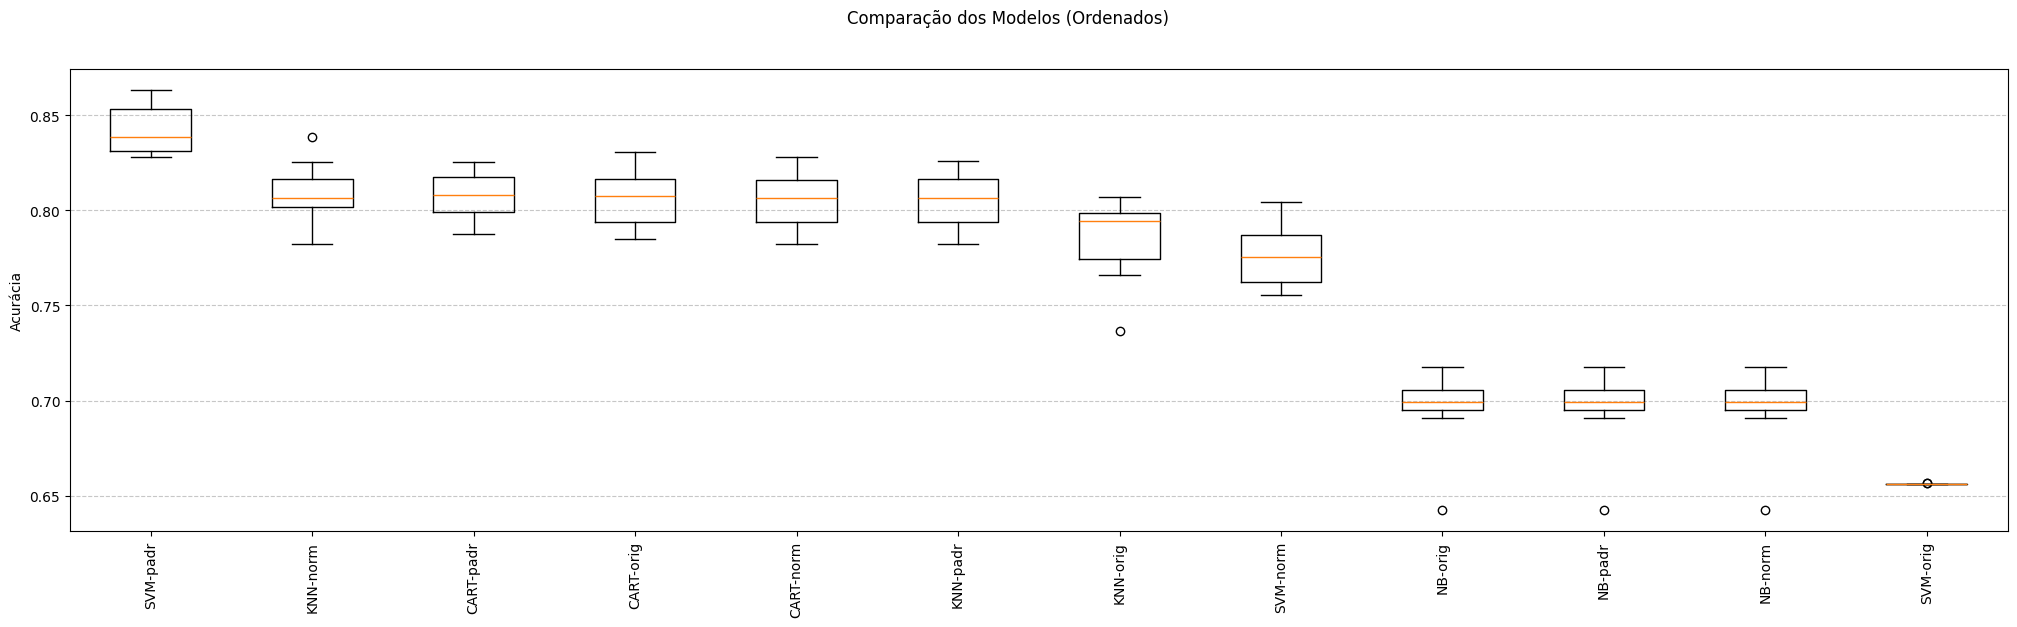

In [ ]:
np.random.seed(7) # definindo uma semente global para este bloco

# Listas para armazenar os armazenar os pipelines e os resultados para todas as visões do dataset
pipelines = []
results = []


# Criando os elementos do pipeline

# Algoritmos que serão utilizados
# Modelos
models = [
    ('KNN', KNeighborsClassifier()),
    ('CART', DecisionTreeClassifier()),
    ('NB', GaussianNB()),
    ('SVM', SVC())
]

# PREPROCESSORS

# 1. ORIGINAL (sem scaling nas numéricas)
preprocessor_orig = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
        ("num", "passthrough", numerical_cols)
    ]
)

# 2. PADRONIZAÇÃO
preprocessor_standard = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
        ("num", StandardScaler(), numerical_cols)
    ]
)

# 3. NORMALIZAÇÃO
preprocessor_minmax = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
        ("num", MinMaxScaler(), numerical_cols)
    ]
)

# Lista de configurações
configs = [
    ("orig", preprocessor_orig),
    ("padr", preprocessor_standard),
    ("norm", preprocessor_minmax)
]

# LOOP CORRETO

for config_name, preprocessor in configs:
    for model_name, model in models:

        name = f"{model_name}-{config_name}"

        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("model", model)
        ])

        cv_results = cross_val_score(
            pipeline,
            X_train,
            y_train,
            cv=kfold,
            scoring=scoring
        )

        results.append({
            'name': name,
            'results': cv_results,
            'mean': cv_results.mean(),
            'std': cv_results.std()
        })


# Ordenar a lista do melhor para o pior com base na média (mean)
results.sort(key=lambda x: x['mean'], reverse=True)


# Imprimir resultados ordenados
print("--- Modelos Ordenados por Performance (Acurácia) ---")
for item in results:
    print(f"{item['name']}: {item['mean']:.3f} ({item['std']:.3f})")

# Gráfico
sorted_names = [item['name'] for item in results]
sorted_results = [item['results'] for item in results]

fig = plt.figure(figsize=(25,6))
fig.suptitle('Comparação dos Modelos (Ordenados)')
ax = fig.add_subplot(111)

plt.boxplot(sorted_results)
ax.set_xticklabels(sorted_names, rotation=90)
plt.ylabel('Acurácia')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.show()

### Otimização dos Hiperparâmetros (Tuning)

Durante o processo de otimização de hiperparâmetros, também foram realizados testes utilizando o algoritmo Support Vector Machine (SVM).
No entanto, observou-se que o tempo de processamento do SVM foi significativamente mais elevado em comparação com os demais modelos, especialmente durante a execução do GridSearchCV, que avalia múltiplas combinações de parâmetros.

Por outro lado, o algoritmo K-Nearest Neighbors (KNN) apresentou um desempenho competitivo em termos de acurácia, aliado a um tempo de processamento consideravelmente mais eficiente.

Dessa forma, considerando o contexto do MVP — que prioriza simplicidade, desempenho e viabilidade prática — optou-se por utilizar o KNN como modelo principal, equilibrando custo computacional e qualidade dos resultados.


Os hiperparâmetros são configurações do modelo que não são aprendidas automaticamente durante o treinamento, sendo necessário defini-los previamente. No caso do KNN, destacam-se:

- **n_neighbors**: número de vizinhos considerados na classificação
- **metric**: métrica de distância utilizada para calcular a similaridade entre os pontos

Para encontrar a melhor combinação desses parâmetros, foi utilizado o método **GridSearchCV**, que testa todas as combinações possíveis definidas em um grid de parâmetros.

Além disso, a otimização foi realizada considerando diferentes estratégias de pré-processamento dos dados:

- Dados originais (sem normalização)
- Dados padronizados (StandardScaler)
- Dados normalizados (MinMaxScaler)

Cada combinação de pré-processamento e hiperparâmetros foi avaliada utilizando **validação cruzada estratificada (Stratified K-Fold)**, garantindo uma estimativa robusta do desempenho do modelo.

O uso de **Pipeline** assegura que o pré-processamento e o treinamento do modelo sejam aplicados corretamente dentro de cada partição da validação cruzada, evitando vazamento de dados.

Ao final, para cada configuração, é exibida a melhor acurácia obtida e os respectivos hiperparâmetros, permitindo a seleção do modelo mais eficiente.

In [ ]:
# Tuning do KNN

np.random.seed(7)

# PREPROCESSORS (igual ao bloco anterior)

preprocessor_orig = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
        ("num", "passthrough", numerical_cols)
    ]
)

preprocessor_standard = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
        ("num", StandardScaler(), numerical_cols)
    ]
)

preprocessor_minmax = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
        ("num", MinMaxScaler(), numerical_cols)
    ]
)

# CONFIGURAÇÕES
configs = [
    ("orig", preprocessor_orig),
    ("padr", preprocessor_standard),
    ("norm", preprocessor_minmax)
]

# GRID DE PARÂMETROS (ATUALIZADO)
param_grid = {
    'model__n_neighbors': [1,3,5,7,9,11,13,15,17,19,21],
    'model__metric': ["euclidean", "manhattan", "minkowski"],
}

# LOOP DE TUNING
for name, preprocessor in configs:

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", KNeighborsClassifier())
    ])

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring=scoring,
        cv=kfold
    )

    grid.fit(X_train, y_train)

    print(f"{name} - Melhor: {grid.best_score_:.3f} usando {grid.best_params_}")

orig - Melhor: 0.807 usando {'model__metric': 'manhattan', 'model__n_neighbors': 11}
padr - Melhor: 0.822 usando {'model__metric': 'manhattan', 'model__n_neighbors': 11}
norm - Melhor: 0.816 usando {'model__metric': 'manhattan', 'model__n_neighbors': 9}


## Finalização do Modelo e Avaliação no Conjunto de Teste

Após a etapa de comparação entre diferentes algoritmos e otimização de hiperparâmetros, foi definido o modelo final a ser utilizado.

O modelo escolhido foi o **K-Nearest Neighbors (KNN)**, utilizando:

- Métrica de distância: **Manhattan**
- Número de vizinhos: **11**
- Pré-processamento: **OneHotEncoder (variáveis categóricas) + StandardScaler (variáveis numéricas)**

Para garantir consistência entre treino e produção, foi utilizado um **Pipeline**, que encapsula todas as etapas de transformação e modelagem.

O modelo foi então treinado utilizando o conjunto de treino e avaliado no conjunto de teste (holdout), que não foi utilizado durante o treinamento.

A acurácia obtida no conjunto de teste foi:

**Acurácia: 0.829**

Esse resultado indica que o modelo é capaz de realizar previsões corretas em aproximadamente **82,9% dos casos**, demonstrando um bom desempenho para o problema proposto.

A utilização do conjunto de teste garante uma avaliação mais realista do modelo, simulando seu comportamento em dados não vistos.

Em seguida foi realizado o fit com todos os dados

In [ ]:
# Avaliação do modelo com o conjunto de testes KNN

# Pipeline completo (igual ao tuning)

pipeline = Pipeline([
    ("preprocessor", ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
            ("num", StandardScaler(), numerical_cols)
        ]
    )),
    ("model", KNeighborsClassifier(metric='manhattan', n_neighbors=11))
])

# Treino
pipeline.fit(X_train, y_train)

# Predição
predictions = pipeline.predict(X_test)

# Avaliação
print(accuracy_score(y_test, predictions))

0.8292158968850698


In [ ]:
# Preparação do modelo com TODO o dataset
pipeline = Pipeline([
    ("preprocessor", ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
            ("num", StandardScaler(), numerical_cols)
        ]
    )),
    ("model", KNeighborsClassifier(metric='manhattan', n_neighbors=11))
])

pipeline.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Education', 'City',
                                                   'Gender', 'EverBenched']),
                                                 ('num', StandardScaler(),
                                                  ['JoiningYear', 'PaymentTier',
                                                   'Age',
                                                   'ExperienceInCurrentDomain'])])),
                ('model',
                 KNeighborsClassifier(metric='manhattan', n_neighbors=11))])

##  Simulação do Modelo com Dados Não Vistos

Nesta etapa, realizamos uma simulação prática da aplicação do modelo utilizando novos dados, representando um cenário real de uso.

Foram criados exemplos de funcionários com características como nível educacional, cidade, idade e experiência, simulando entradas que poderiam ser fornecidas por um usuário em uma aplicação real.

Os dados foram mantidos em formato textual (dados brutos), sem qualquer transformação manual, pois o **Pipeline previamente definido é responsável por aplicar automaticamente todas as etapas de pré-processamento**, incluindo:

- Codificação das variáveis categóricas (OneHotEncoder)
- Padronização das variáveis numéricas (StandardScaler)

Isso garante que o mesmo fluxo utilizado no treinamento seja aplicado durante a predição, evitando inconsistências entre treino e produção.

O modelo então realiza a predição para cada novo registro, classificando os funcionários em:

- **SAIRÁ**: maior probabilidade de deixar a empresa
- **FICARÁ**: maior probabilidade de permanência

Essa simulação demonstra que o modelo está pronto para ser integrado a uma aplicação real, sendo capaz de receber dados diretamente do usuário e gerar previsões automaticamente.





In [ ]:
# Dados de teste (Texto humano)
data_simulacao = {
    'Education': ['Bachelors', 'Masters', 'PHD','Bachelors'],
    'JoiningYear': [2017, 2013, 2015, 2012],
    'City': ['Bangalore', 'Pune', 'New Delhi','Bangalore'],
    'PaymentTier': [3, 1, 3, 3],
    'Age': [34, 28, 40, 37],
    'Gender': ['Male', 'Female', 'Female', 'Male'],
    'EverBenched': ['No', 'No', 'No', 'No'],
    'ExperienceInCurrentDomain': [0, 3, 5, 4]
}

#  Apenas criar DataFrame (SEM encoding manual)
df_entrada = pd.DataFrame(data_simulacao)

#  Predição direta (pipeline faz tudo)
predicoes = pipeline.predict(df_entrada)

# Resultado
print("\n--- Diagnóstico de Retenção ---")
for i, p in enumerate(predicoes):
    resultado = "SAIRÁ" if p == 1 else "FICARÁ"
    print(f"Funcionário {i+1} ({data_simulacao['Education'][i]}): {resultado}")




--- Diagnóstico de Retenção ---
Funcionário 1 (Bachelors): FICARÁ
Funcionário 2 (Masters): FICARÁ
Funcionário 3 (PHD): FICARÁ
Funcionário 4 (Bachelors): FICARÁ


##  Exportação do Modelo para Uso na Aplicação

Após a definição e treinamento do modelo final, foi realizada a sua exportação para utilização na aplicação full stack.

Foi utilizado o módulo `pickle` para serializar o modelo treinado em um arquivo binário, permitindo que ele seja carregado posteriormente pelo back-end da aplicação.

Diferentemente de abordagens tradicionais, foi exportado o **Pipeline completo**, que inclui:

- Codificação das variáveis categóricas (OneHotEncoder)
- Padronização das variáveis numéricas (StandardScaler)
- Modelo de classificação (KNN)

Essa abordagem garante que todas as etapas de pré-processamento e predição sejam executadas de forma consistente em ambiente de produção, sem necessidade de transformações manuais adicionais.

O arquivo gerado pode ser carregado diretamente pela API, permitindo que novos dados sejam processados e classificados de forma automática.

Essa estratégia reduz a complexidade do código no back-end e evita inconsistências entre o ambiente de treinamento e o ambiente de execução.

In [ ]:
# 1. Salvar o Pipeline (que já contém o StandardScaler + SVM Tunado)
import pickle

# salvar SOMENTE o pipeline completo
with open("modelo_retencao_v20260412_2.pkl", "wb") as f:
    pickle.dump(pipeline, f)

print("Modelo exportado com sucesso!")

Modelo exportado com sucesso!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

##  Conclusão

O modelo desenvolvido apresentou bom desempenho na previsão de retenção de funcionários.

A utilização de pipelines garantiu consistência no processamento dos dados, enquanto a comparação entre diferentes algoritmos permitiu a escolha da melhor abordagem.

Como trabalhos futuros, pode-se explorar técnicas de balanceamento de classes e modelos mais complexos.


###  Considerações de Segurança

O dataset utilizado não contém informações que permitam identificar diretamente os funcionários ou a empresa, não havendo dados pessoais sensíveis como nome, CPF ou identificadores únicos.

No entanto, algumas variáveis presentes, como idade e gênero, podem ser consideradas dados sensíveis em determinados contextos, especialmente sob a perspectiva de privacidade e legislação (como a LGPD).

Em um cenário real de aplicação, seria recomendável:

- Aplicar técnicas de anonimização ou generalização de dados
- Avaliar possíveis vieses do modelo relacionados a gênero, idade ou localização
- Garantir que o modelo não produza decisões discriminatórias
- Implementar controles de acesso e proteção dos dados utilizados

Dessa forma, reforça-se a importância de alinhar o desenvolvimento de soluções de Machine Learning com boas práticas de segurança e ética no uso de dados.